# Capstone natación — Exploración 1

**Pregunta:** el factor de conversión entre piscina de 25 m y de 50 m,
¿es el mismo en todos los estilos y distancias?

**La idea.** En piscina de 25 m se dan el doble de vueltas que en 50 m para la misma
distancia. Cada vuelta regala tiempo: el nadador empuja la pared y viaja bajo el agua,
que es más rápido que nadar en superficie. Las vueltas extra son exactamente
`distancia / 50`:

| Prueba | Vueltas en 25 m | Vueltas en 50 m | Extra |
|--------|-----------------|-----------------|-------|
| 50 m   | 1               | 0               | **1** |
| 100 m  | 3               | 1               | **2** |
| 200 m  | 7               | 3               | **4** |
| 400 m  | 15              | 7               | **8** |

Si cada vuelta valiera siempre lo mismo, la diferencia entre ambas piscinas crecería
en proporción exacta a esa cuenta. Vamos a ver si es así.

**Sobre los datos.** `descargar.py` usa el modo `BEST_TIMES` de la API: devuelve la
mejor marca del año de cada nadador, una fila por persona y prueba. Llegamos a eso
después de descubrir que la API no pagina y que pedir "los 5.000 mejores tiempos"
traía 30 nadadores repetidos.

---

## 1. Cargar los datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

df = pd.read_csv("datos/nados.csv")
print("Filas:", f"{len(df):,}", " Columnas:", df.shape[1])
df.head()

Filas: 193,142  Columnas: 25


,anio,sexo,piscina,distancia,estilo,prueba,rank,tiempo,tiempo_s,puntos_fina,nombre,person_id,fecha_nacimiento,edad,pais,pais_codigo,club,fecha,competencia,ciudad,medalla,record,result_id,event_id,discipline_id
0,2024,M,LCM,50,FREESTYLE,Men's 50m Freestyle,1,21.13,21.13,969.0,MCEVOY Cameron,9f6cbeb2-7f23-4d65-aae9-4d934caf9785,1994-05-13T00:00:00,29.0,Australia,AUS,No,2024-02-16T00:00:00,World Aquatics Championships - Doha 2024,Doha,NaN,NaN,R1000604,7dc47aca-99a9-4719-aedc-41118d97be8a,54f8e2e1-0506-47f3-bc16-14648cee1369
1,2024,M,LCM,50,FREESTYLE,Men's 50m Freestyle,2,21.25,21.25,952.0,PROUD Benjamin,e267cb35-3d81-4548-aab2-dd1d00ca78d6,1994-09-21T00:00:00,29.0,Great Britain,GBR,University of Bath SC,2024-04-06T00:00:00,GBR Championships 2024,London,1.0,NaN,R1000849,2ab874b4-94e0-46d9-9342-8ce02f42b5d7,54f8e2e1-0506-47f3-bc16-14648cee1369
2,2024,M,LCM,50,FREESTYLE,Men's 50m Freestyle,3,21.38,21.38,935.0,BUKHOV Vladyslav,56aaa233-94a5-45cf-bfd8-e72b28c7431d,2002-07-05T00:00:00,21.0,Ukraine,UKR,No,2024-02-16T00:00:00,World Aquatics Championships - Doha 2024,Doha,NaN,[0],R1190363,7dc47aca-99a9-4719-aedc-41118d97be8a,54f8e2e1-0506-47f3-bc16-14648cee1369
3,2024,M,LCM,50,FREESTYLE,Men's 50m Freestyle,4,21.41,21.41,931.0,DRESSEL Caeleb,7678b6fd-787d-4168-a4b0-9ac07411d82e,1996-08-16T00:00:00,27.0,United States of America,USA,GSC-FL,2024-06-21T00:00:00,2024 U.S. Olympic Trials,Indianapolis,1.0,NaN,R1036454,b839ffd9-239c-4aca-9274-b8d7f6f432fc,54f8e2e1-0506-47f3-bc16-14648cee1369
4,2024,M,LCM,50,FREESTYLE,Men's 50m Freestyle,5,21.48,21.48,922.0,LIENDO Josh,43e5171b-2c68-469a-bdfb-9431c8115a71,2002-08-20T00:00:00,21.0,Canada,CAN,North York Aquatic Club,2024-05-18T00:00:00,2024 Bell Canadian Trials,Toronto,1.0,[0],R1159165,e14e1b60-db09-43b9-8cc6-ee9ac47e6b68,54f8e2e1-0506-47f3-bc16-14648cee1369


In [2]:
# Tipos y faltantes: esto responde directo al criterio 2 de la rúbrica
resumen = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "% nulos": (df.isna().mean() * 100).round(1),
    "distintos": df.nunique(),
})
resumen

,tipo,nulos,% nulos,distintos
anio,int64,0,0.0,1
sexo,str,0,0.0,2
piscina,str,0,0.0,2
distancia,int64,0,0.0,4
estilo,str,0,0.0,5
prueba,str,0,0.0,24
rank,int64,0,0.0,5000
tiempo,str,0,0.0,25755
tiempo_s,float64,0,0.0,25755
puntos_fina,float64,0,0.0,968


In [3]:
print("Nadadores distintos:", f"{df['person_id'].nunique():,}")
print("Países:", df["pais"].nunique())
print("Competencias:", df["competencia"].nunique())
print()
print(df.groupby(["sexo", "piscina"]).size().unstack(fill_value=0))

Nadadores distintos: 56,035
Países: 201
Competencias: 306

piscina    LCM    SCM
sexo                 
F        56056  37738
M        57663  41685


## 2. Verificar que cada fila sea un nadador distinto

Este control es el que faltaba en la primera versión y por eso el error pasó
desapercibido. `BEST_TIMES` promete una fila por nadador en cada prueba y piscina.
Hay que comprobarlo, no confiar.

In [4]:
llave = ["sexo", "distancia", "estilo", "piscina", "person_id"]
repetidos = df.duplicated(subset=llave).sum()
print("Filas duplicadas por (sexo, distancia, estilo, piscina, nadador):", repetidos)
assert repetidos == 0, "Hay nadadores repetidos: revisar la descarga antes de seguir"
print("OK — cada fila es un nadador distinto en su prueba y piscina.")

Filas duplicadas por (sexo, distancia, estilo, piscina, nadador): 0
OK — cada fila es un nadador distinto en su prueba y piscina.


## 3. Limpieza

Dos revisiones: tiempos que no se pudieron convertir a segundos, y tiempos absurdos.
Para lo segundo usamos los **segundos por metro**, que hace comparables pruebas de
distinta distancia.

In [5]:
print("Sin tiempo utilizable :", df["tiempo_s"].isna().sum())
print("Sin person_id         :", df["person_id"].isna().sum())
df = df.dropna(subset=["tiempo_s", "person_id"]).copy()

df["s_por_metro"] = df["tiempo_s"] / df["distancia"]
print("\nDistribución de segundos por metro:")
print(df["s_por_metro"].describe(percentiles=[.01, .5, .99]).round(3))

Sin tiempo utilizable : 0
Sin person_id         : 0

Distribución de segundos por metro:
count    193142.000
mean          0.667
std           0.110
min           0.398
1%            0.466
50%           0.659
99%           0.984
max           3.076
Name: s_por_metro, dtype: float64


In [6]:
# El 99% de los nados está bajo ~1.1 s/m. Cortamos en 2.0, que es
# generoso: solo saca lo que casi seguro es un error de registro.
LIM_BAJO, LIM_ALTO = 0.38, 2.0
fuera = df[(df["s_por_metro"] < LIM_BAJO) | (df["s_por_metro"] > LIM_ALTO)]
print(f"Nados fuera del rango [{LIM_BAJO}, {LIM_ALTO}] s/m: {len(fuera)} de {len(df):,}")
if len(fuera):
    print(fuera[["prueba", "piscina", "nombre", "pais", "tiempo", "s_por_metro"]]
          .head(10).to_string(index=False))

df = df[df["s_por_metro"].between(LIM_BAJO, LIM_ALTO)].copy()
print("\nFilas que quedan:", f"{len(df):,}")

Nados fuera del rango [0.38, 2.0] s/m: 3 de 193,142
                   prueba piscina         nombre   pais  tiempo  s_por_metro
   Women's 200m Freestyle     SCM JOHANSSON Lova Sweden 8:23.48       2.5174
  Women's 100m Backstroke     SCM JOHANSSON Lova Sweden 4:25.04       2.6504
Women's 100m Breaststroke     SCM JOHANSSON Lova Sweden 5:07.61       3.0761

Filas que quedan: 193,139


## 4. El cruce: los que nadaron en las dos piscinas

El corazón del proyecto. Cruzamos cada nadador **consigo mismo**: su marca en
piscina de 50 contra su marca en piscina de 25, misma prueba, mismo año. Comparar
a alguien con su propia marca elimina de un plumazo el talento, la edad, el
entrenamiento y todo lo demás que separaría a dos personas distintas.

In [7]:
llaves = ["anio", "sexo", "distancia", "estilo", "person_id"]
largo = df[df["piscina"] == "LCM"]
corto = df[df["piscina"] == "SCM"]

pares = largo.merge(
    corto[llaves + ["tiempo_s", "tiempo", "fecha", "competencia"]],
    on=llaves, suffixes=("_lcm", "_scm"),
)

pares["diferencia_s"]  = pares["tiempo_s_lcm"] - pares["tiempo_s_scm"]
pares["factor"]        = pares["tiempo_s_lcm"] / pares["tiempo_s_scm"]
pares["vueltas_extra"] = pares["distancia"] / 50
pares["por_vuelta_s"]  = pares["diferencia_s"] / pares["vueltas_extra"]

print("Nadadores con marca en ambas piscinas:", f"{len(pares):,}")
print("De un total de", f"{df['person_id'].nunique():,}", "nadadores en la muestra")
print("\nPares por prueba:")
print(pares.groupby(["sexo", "prueba"]).size().to_string())

Nadadores con marca en ambas piscinas: 30,257
De un total de 56,034 nadadores en la muestra

Pares por prueba:
sexo  prueba                   
F     Women's 100m Backstroke      1453
      Women's 100m Breaststroke    1423
      Women's 100m Butterfly       1436
      Women's 100m Freestyle       1677
      Women's 200m Backstroke       988
      Women's 200m Breaststroke     998
      Women's 200m Butterfly        649
      Women's 200m Freestyle       1470
      Women's 200m Medley           968
      Women's 400m Freestyle       1145
      Women's 400m Medley           570
      Women's 50m Freestyle        1692
M     Men's 100m Backstroke        1366
      Men's 100m Breaststroke      1563
      Men's 100m Butterfly         1542
      Men's 100m Freestyle         1745
      Men's 200m Backstroke         989
      Men's 200m Breaststroke      1150
      Men's 200m Butterfly          926
      Men's 200m Freestyle         1620
      Men's 200m Medley            1073
      Men's 400m 

In [8]:
# Control de sanidad: la piscina de 25 m debería ser más rápida casi siempre.
al_reves = (pares["diferencia_s"] < 0).sum()
print("Casos donde la piscina de 50 m fue más rápida: {:,} de {:,} ({:.1%})".format(
    al_reves, len(pares), al_reves / len(pares)))
print("\nNo son errores: son nadadores que ese año estuvieron en forma en una")
print("temporada y no en la otra. Los dejamos y lo comentamos en el informe.\n")

pares[["sexo", "prueba", "nombre", "pais", "tiempo_lcm", "tiempo_scm",
       "diferencia_s", "factor", "por_vuelta_s"]].head(10)

Casos donde la piscina de 50 m fue más rápida: 3,466 de 30,257 (11.5%)

No son errores: son nadadores que ese año estuvieron en forma en una
temporada y no en la otra. Los dejamos y lo comentamos en el informe.



,sexo,prueba,nombre,pais,tiempo_lcm,tiempo_scm,diferencia_s,factor,por_vuelta_s
0,M,Men's 50m Freestyle,LIENDO Josh,Canada,21.48,20.88,0.60,1.028736,0.60
1,M,Men's 50m Freestyle,DEPLANO Leonardo,Italy,21.50,20.83,0.67,1.032165,0.67
2,M,Men's 50m Freestyle,CROOKS Jordan,Cayman Islands,21.51,19.90,1.61,1.080905,1.61
3,M,Men's 50m Freestyle,GUILIANO Chris,United States of America,21.59,20.72,0.87,1.041988,0.87
4,M,Men's 50m Freestyle,GROUSSET Maxime,France,21.60,20.78,0.82,1.039461,0.82
5,M,Men's 50m Freestyle,ZAZZERI Lorenzo,Italy,21.64,21.37,0.27,1.012635,0.27
6,M,Men's 50m Freestyle,JACK Jamie,Australia,21.66,20.89,0.77,1.036860,0.77
7,M,Men's 50m Freestyle,ALEXY Jack,United States of America,21.66,20.51,1.15,1.056070,1.15
8,M,Men's 50m Freestyle,KORNEV Egor,Neutral Athletes B,21.70,20.75,0.95,1.045783,0.95
9,M,Men's 50m Freestyle,ANDREW Michael,United States of America,21.70,21.49,0.21,1.009772,0.21


## 5. El resultado

Dos formas de mirar lo mismo. El **factor** es lo que usa la gente en la práctica:
por cuánto multiplicar para pasar de una piscina a la otra. La **ventaja por vuelta**
es la que permite juzgar si el modelo simple se sostiene.

In [9]:
tabla = (pares.groupby(["sexo", "estilo", "distancia"])
              .agg(n=("factor", "size"),
                   factor_mediana=("factor", "median"),
                   dif_mediana_s=("diferencia_s", "median"),
                   por_vuelta_s=("por_vuelta_s", "median"),
                   por_vuelta_q1=("por_vuelta_s", lambda x: x.quantile(.25)),
                   por_vuelta_q3=("por_vuelta_s", lambda x: x.quantile(.75)))
              .round(3))
tabla

n  factor_mediana  dif_mediana_s  por_vuelta_s  por_vuelta_q1  por_vuelta_q3
sexo estilo       distancia                                                                                 
F    BACKSTROKE   100        1453           1.041          2.630         1.315          0.845          1.825
                  200         988           1.041          5.820         1.455          0.956          1.977
     BREASTSTROKE 100        1423           1.033          2.450         1.225          0.620          1.790
                  200         998           1.033          5.215         1.304          0.703          1.974
     BUTTERFLY    100        1436           1.015          0.935         0.467         -0.036          0.916
                  200         649           1.025          3.480         0.870          0.400          1.418
     FREESTYLE    50         1692           1.020          0.530         0.530          0.140          0.890
                  100        1677           1.020          1.140         0.570          0.180          0.930
                  200        1470           1.023          2.850         0.712          0.296          1.133
                  400        1145           1.025          6.730         0.841          0.414          1.281
     MEDLEY       200         968           1.031          4.320         1.080          0.636          1.535
                  400         570           1.033          9.845         1.231          0.762          1.679
M    BACKSTROKE   100        1366           1.049          2.760         1.380          0.950          1.830
                  200         989           1.052          6.500         1.625          1.102          2.140
     BREASTSTROKE 100        1563           1.041          2.630         1.315          0.852          1.807
                  200        1150           1.045          6.205         1.551          1.026          2.210
     BUTTERFLY    100        1542           1.020          1.130         0.565          0.086          0.930
                  200         926           1.034          4.190         1.047          0.523          1.552
     FREESTYLE    50         1747           1.029          0.670         0.670          0.300          1.010
                  100        1745           1.030          1.540         0.770          0.385          1.075
                  200        1620           1.033          3.605         0.901          0.449          1.265
                  400        1336           1.032          7.700         0.963          0.518          1.413
     MEDLEY       200        1073           1.039          4.940         1.235          0.760          1.682
                  400         731           1.040         10.840         1.355          0.891          1.879

### Las dos preguntas, contestadas con la tabla

1. ¿Vale lo mismo una vuelta en todos los estilos?
2. Dentro de un estilo, ¿vale lo mismo en todas las distancias?

Si la respuesta a las dos fuera "sí", la tabla siguiente sería plana.

In [10]:
pivote = (pares.groupby(["sexo", "estilo", "distancia"])["por_vuelta_s"]
               .median().unstack().round(3))
print("Segundos ganados por vuelta extra (mediana)\n")
print(pivote.to_string())

print("\n\nRazón entre el estilo que más gana y el que menos, por distancia:")
por_estilo = pares.groupby(["estilo", "distancia"])["por_vuelta_s"].median().unstack()
print((por_estilo.max() / por_estilo.min()).round(2).to_string())

Segundos ganados por vuelta extra (mediana)

distancia           50     100    200    400
sexo estilo                                 
F    BACKSTROKE     NaN  1.315  1.455    NaN
     BREASTSTROKE   NaN  1.225  1.304    NaN
     BUTTERFLY      NaN  0.467  0.870    NaN
     FREESTYLE     0.53  0.570  0.712  0.841
     MEDLEY         NaN    NaN  1.080  1.231
M    BACKSTROKE     NaN  1.380  1.625    NaN
     BREASTSTROKE   NaN  1.315  1.551    NaN
     BUTTERFLY      NaN  0.565  1.047    NaN
     FREESTYLE     0.67  0.770  0.901  0.963
     MEDLEY         NaN    NaN  1.235  1.355


Razón entre el estilo que más gana y el que menos, por distancia:
distancia
50     1.00
100    2.63
200    1.90
400    1.42


## 6. Gráficos

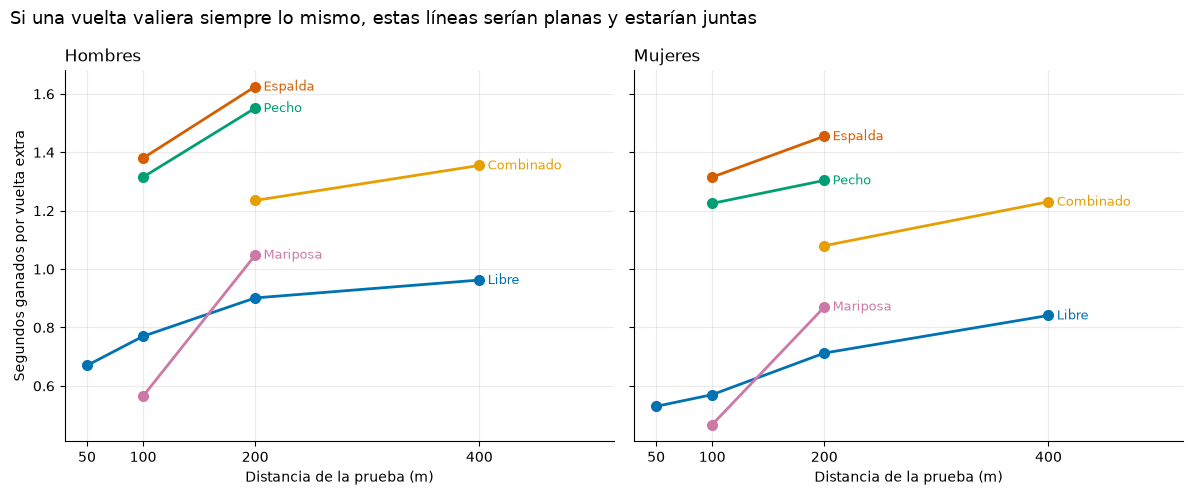

In [11]:
# Paleta Okabe-Ito: distinguible también para daltonismo
COLORES = {"FREESTYLE": "#0072B2", "BACKSTROKE": "#D55E00",
           "BREASTSTROKE": "#009E73", "BUTTERFLY": "#CC79A7",
           "MEDLEY": "#E69F00"}
NOMBRES = {"FREESTYLE": "Libre", "BACKSTROKE": "Espalda",
           "BREASTSTROKE": "Pecho", "BUTTERFLY": "Mariposa", "MEDLEY": "Combinado"}
GRIS = "#6E878D"

fig, ejes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, sexo, titulo in zip(ejes, ["M", "F"], ["Hombres", "Mujeres"]):
    d = pares[pares["sexo"] == sexo]
    for estilo in ["FREESTYLE", "BUTTERFLY", "MEDLEY", "BREASTSTROKE", "BACKSTROKE"]:
        s = d[d["estilo"] == estilo].groupby("distancia")["por_vuelta_s"].median()
        if s.empty:
            continue
        ax.plot(s.index, s.values, marker="o", markersize=7, linewidth=2,
                color=COLORES[estilo], label=NOMBRES[estilo])
        ax.annotate(NOMBRES[estilo], (s.index[-1], s.values[-1]),
                    xytext=(6, 0), textcoords="offset points",
                    color=COLORES[estilo], fontsize=9, va="center")
    ax.set_title(titulo, fontsize=12, loc="left")
    ax.set_xlabel("Distancia de la prueba (m)")
    ax.set_xticks([50, 100, 200, 400])
    ax.grid(alpha=.25)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlim(30, 520)

ejes[0].set_ylabel("Segundos ganados por vuelta extra")
fig.suptitle("Si una vuelta valiera siempre lo mismo, estas líneas serían planas y estarían juntas",
             fontsize=13, x=0.01, ha="left")
plt.tight_layout()
plt.show()

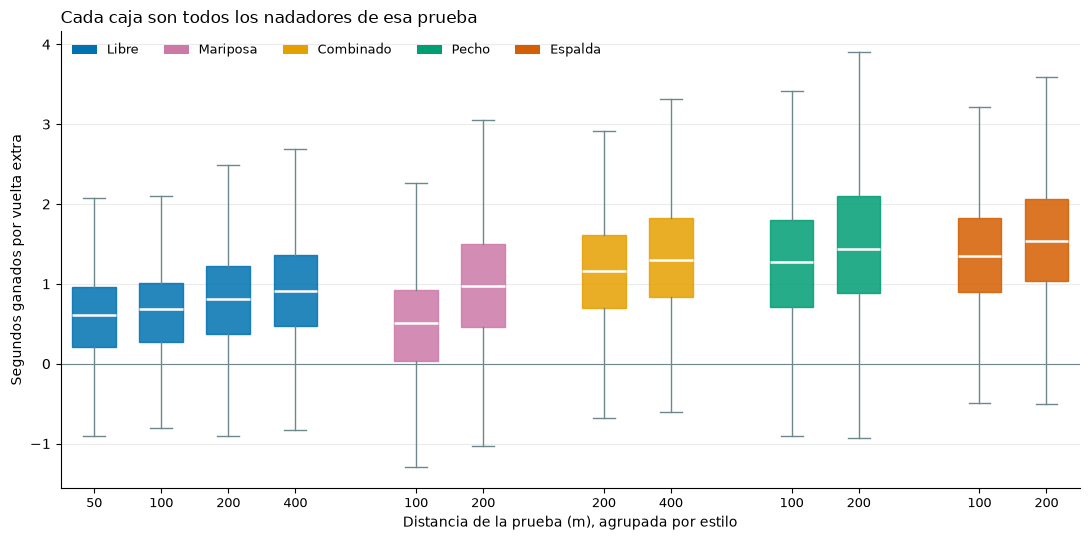

In [12]:
# La dispersión detrás de cada mediana: no todos los nadadores ganan lo mismo
fig, ax = plt.subplots(figsize=(11, 5.5))
orden = ["FREESTYLE", "BUTTERFLY", "MEDLEY", "BREASTSTROKE", "BACKSTROKE"]
etiquetas, posiciones, datos, colores = [], [], [], []
p = 0
for estilo in orden:
    for dist in sorted(pares[pares["estilo"] == estilo]["distancia"].unique()):
        v = pares[(pares["estilo"] == estilo) & (pares["distancia"] == dist)]["por_vuelta_s"]
        if len(v) < 30:
            continue
        datos.append(v.values); posiciones.append(p); colores.append(COLORES[estilo])
        etiquetas.append(f"{dist}"); p += 1
    p += 0.8

bp = ax.boxplot(datos, positions=posiciones, widths=.65, patch_artist=True,
                showfliers=False, medianprops=dict(color="white", linewidth=1.8))
for caja, c in zip(bp["boxes"], colores):
    caja.set(facecolor=c, edgecolor=c, alpha=.85)
for parte in ["whiskers", "caps"]:
    for art in bp[parte]:
        art.set(color=GRIS, linewidth=1)

ax.set_xticks(posiciones); ax.set_xticklabels(etiquetas, fontsize=9)
ax.set_xlabel("Distancia de la prueba (m), agrupada por estilo")
ax.set_ylabel("Segundos ganados por vuelta extra")
ax.set_title("Cada caja son todos los nadadores de esa prueba", fontsize=12, loc="left")
ax.axhline(0, color=GRIS, linewidth=.8)
ax.grid(axis="y", alpha=.25)
ax.spines[["top", "right"]].set_visible(False)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=COLORES[e], label=NOMBRES[e]) for e in orden],
          frameon=False, ncol=5, loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## 7. Guardar

Estos dos archivos son el avance que le muestras a Javier.

In [13]:
pares.to_csv("datos/pares_lcm_scm.csv", index=False)
tabla.to_csv("datos/factores_por_prueba.csv")
print("Guardados:")
print("  datos/pares_lcm_scm.csv      ", f"{len(pares):,}", "nadadores con marca en ambas piscinas")
print("  datos/factores_por_prueba.csv", len(tabla), "combinaciones de sexo x estilo x distancia")

Guardados:
  datos/pares_lcm_scm.csv       30,257 nadadores con marca en ambas piscinas
  datos/factores_por_prueba.csv 24 combinaciones de sexo x estilo x distancia


---

## Lo que sigue

- **Inferencia** (clase 5, ma 8-sep): intervalo de confianza para la ventaja por
  vuelta de cada estilo, y prueba de hipótesis para si hombres y mujeres se
  benefician igual.
- **Regresión** (clase 6, ju 10-sep): `diferencia_s ~ vueltas_extra` separada por
  estilo. La pendiente es la ventaja por vuelta; el intercepto dice si hay algo
  más en juego además de las vueltas.
- **Ampliar**: agregar años en `ANIOS` dentro de `descargar.py` permitiría ver si
  el efecto se mueve en el tiempo.

### Limitaciones que hay que declarar en el informe

1. Nos quedamos con los 5.000 mejores nadadores de cada prueba, no con una muestra
   al azar. Los resultados describen a la élite.
2. Un nadador puede haber estado en distinta forma en la temporada de piscina corta
   que en la de larga. Al comparar medianas sobre miles de casos eso se promedia,
   pero no desaparece.
3. Un solo año, 2024.